In [378]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
from nltk.stem.porter import PorterStemmer
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay


In [379]:
dataset = pd.read_csv('twitter_dataset.csv')

In [380]:
dataset.head()

,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
0,570306133677760513,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada)
1,570301130888122368,positive,0.3486,NaN,0.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials t...,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada)
2,570301083672813571,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I n...,NaN,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada)
3,570301031407624196,negative,1.0000,Bad Flight,0.7033,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica it's really aggressive to blast...,NaN,2015-02-24 11:15:36 -0800,NaN,Pacific Time (US & Canada)
4,570300817074462722,negative,1.0000,Can't Tell,1.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica and it's a really big bad thing...,NaN,2015-02-24 11:14:45 -0800,NaN,Pacific Time (US & Canada)


In [381]:
dataset.tail()

,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
14635,569587686496825344,positive,0.3487,NaN,0.0000,American,NaN,KristenReenders,NaN,0,@AmericanAir thank you we got on a different f...,NaN,2015-02-22 12:01:01 -0800,NaN,NaN
14636,569587371693355008,negative,1.0000,Customer Service Issue,1.0000,American,NaN,itsropes,NaN,0,@AmericanAir leaving over 20 minutes Late Flig...,NaN,2015-02-22 11:59:46 -0800,Texas,NaN
14637,569587242672398336,neutral,1.0000,NaN,NaN,American,NaN,sanyabun,NaN,0,@AmericanAir Please bring American Airlines to...,NaN,2015-02-22 11:59:15 -0800,"Nigeria,lagos",NaN
14638,569587188687634433,negative,1.0000,Customer Service Issue,0.6659,American,NaN,SraJackson,NaN,0,"@AmericanAir you have my money, you change my ...",NaN,2015-02-22 11:59:02 -0800,New Jersey,Eastern Time (US & Canada)
14639,569587140490866689,neutral,0.6771,NaN,0.0000,American,NaN,daviddtwu,NaN,0,@AmericanAir we have 8 ppl so we need 2 know h...,NaN,2015-02-22 11:58:51 -0800,"dallas, TX",NaN


In [382]:
dataset.shape

(14640, 15)

In [383]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14640 entries, 0 to 14639
Data columns (total 15 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   tweet_id                      14640 non-null  int64  
 1   airline_sentiment             14640 non-null  object 
 2   airline_sentiment_confidence  14640 non-null  float64
 3   negativereason                9178 non-null   object 
 4   negativereason_confidence     10522 non-null  float64
 5   airline                       14640 non-null  object 
 6   airline_sentiment_gold        40 non-null     object 
 7   name                          14640 non-null  object 
 8   negativereason_gold           32 non-null     object 
 9   retweet_count                 14640 non-null  int64  
 10  text                          14640 non-null  object 
 11  tweet_coord                   1019 non-null   object 
 12  tweet_created                 14640 non-null  object 
 13  t

In [384]:
dataset = dataset.drop(columns=['tweet_id', 'airline_sentiment_confidence', 'negativereason', 'negativereason_confidence', 'airline_sentiment_gold', 'name', 'negativereason_gold', 'retweet_count', 'tweet_coord', 'tweet_created', 'tweet_location', 'user_timezone'], axis=1)

In [385]:
dataset.head()

,airline_sentiment,airline,text
0,neutral,Virgin America,@VirginAmerica What @dhepburn said.
1,positive,Virgin America,@VirginAmerica plus you've added commercials t...
2,neutral,Virgin America,@VirginAmerica I didn't today... Must mean I n...
3,negative,Virgin America,@VirginAmerica it's really aggressive to blast...
4,negative,Virgin America,@VirginAmerica and it's a really big bad thing...


In [386]:
dataset.isnull().sum()

airline_sentiment    0
airline              0
text                 0
dtype: int64

In [387]:
dataset['airline_sentiment'].value_counts()

airline_sentiment
negative    9178
neutral     3099
positive    2363
Name: count, dtype: int64

**LABEL ENCODING**

In [388]:
mapping = {'positive': 1, 'negative': 0, 'neutral':2}

dataset['airline_sentiment'] = dataset['airline_sentiment'].apply(lambda x: mapping[x])

In [389]:
dataset.head()

,airline_sentiment,airline,text
0,2,Virgin America,@VirginAmerica What @dhepburn said.
1,1,Virgin America,@VirginAmerica plus you've added commercials t...
2,2,Virgin America,@VirginAmerica I didn't today... Must mean I n...
3,0,Virgin America,@VirginAmerica it's really aggressive to blast...
4,0,Virgin America,@VirginAmerica and it's a really big bad thing...


In [390]:
dataset['airline_sentiment'].value_counts()

airline_sentiment
0    9178
2    3099
1    2363
Name: count, dtype: int64

**UNDER SAMPLING**

In [391]:
class_0 = dataset[dataset['airline_sentiment']==0]
class_1 = dataset[dataset['airline_sentiment']==1]
class_2 = dataset[dataset['airline_sentiment']==2]

rows_to_drop = class_0.sample(n=4178, random_state=32)
rows_dropped = class_0.drop(rows_to_drop.index)
new_df = pd.concat([rows_dropped, class_1, class_2], ignore_index=True).sample(frac=1, random_state=43)

In [392]:
new_df.head()

,airline_sentiment,airline,text
2290,0,Delta,"@JetBlue All good, I just have 2 remind myself..."
1665,0,Southwest,@southwestair does anyone realize that banning...
9368,2,Delta,"@JetBlue's CEO #pilots among ardent fans, Wall..."
9415,2,Delta,@JetBlue excited for my first flight w/ you to...
798,0,United,@united #customerservice at @Dulles_Airport co...


In [393]:
new_df.tail()

,airline_sentiment,airline,text
8499,2,Southwest,@SouthwestAir we are trying to go as far away ...
2064,0,Southwest,@SouthwestAir TSA Pre isn't showing up on my b...
7985,2,United,@united I have a LH return business ticket fro...
2303,0,Delta,@jetblue as courtesy to Mosaic members or anyo...
3392,0,US Airways,@USAirways waited for 3 hours NO LUGGAGE line ...


In [394]:
new_df['airline_sentiment'].value_counts()

airline_sentiment
0    5000
2    3099
1    2363
Name: count, dtype: int64

In [395]:
new_df['merged_data'] = new_df['airline'] + " " + new_df['text']

In [396]:
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\perug\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [397]:
new_df.head()

,airline_sentiment,airline,text,merged_data
2290,0,Delta,"@JetBlue All good, I just have 2 remind myself...","Delta @JetBlue All good, I just have 2 remind ..."
1665,0,Southwest,@southwestair does anyone realize that banning...,Southwest @southwestair does anyone realize th...
9368,2,Delta,"@JetBlue's CEO #pilots among ardent fans, Wall...",Delta @JetBlue's CEO #pilots among ardent fans...
9415,2,Delta,@JetBlue excited for my first flight w/ you to...,Delta @JetBlue excited for my first flight w/ ...
798,0,United,@united #customerservice at @Dulles_Airport co...,United @united #customerservice at @Dulles_Air...


In [398]:
def pre_processing(text):
    return re.sub(r'[^a-zA-z]', ' ', text).lower()

porter_stemmer = PorterStemmer()

def stemming(content):
    words = content.split()
    return " ".join([porter_stemmer.stem(word) for word in words if word not in stop_words])

new_df['merged_data'] = new_df['merged_data'].apply(lambda x: stemming(pre_processing(x)))

In [399]:
new_df.head()

,airline_sentiment,airline,text,merged_data
2290,0,Delta,"@JetBlue All good, I just have 2 remind myself...",delta jetblu good remind might hors amp buggi ...
1665,0,Southwest,@southwestair does anyone realize that banning...,southwest southwestair anyon realiz ban peanut...
9368,2,Delta,"@JetBlue's CEO #pilots among ardent fans, Wall...",delta jetblu ceo pilot among ardent fan wall s...
9415,2,Delta,@JetBlue excited for my first flight w/ you to...,delta jetblu excit first flight w today delay ...
798,0,United,@united #customerservice at @Dulles_Airport co...,unit unit customerservic dulles_airport could ...


In [400]:
X = new_df['merged_data']
Y = new_df['airline_sentiment']

In [401]:
print(X)

2290    delta jetblu good remind might hors amp buggi ...
1665    southwest southwestair anyon realiz ban peanut...
9368    delta jetblu ceo pilot among ardent fan wall s...
9415    delta jetblu excit first flight w today delay ...
798     unit unit customerservic dulles_airport could ...
                              ...                        
8499    southwest southwestair tri go far away king sc...
2064    southwest southwestair tsa pre show board pass...
7985    unit unit lh return busi ticket den fra fli do...
2303    delta jetblu courtesi mosaic member anyon requ...
3392    us airway usairway wait hour luggag line long ...
Name: merged_data, Length: 10462, dtype: object


In [402]:
print(Y)

2290    0
1665    0
9368    2
9415    2
798     0
       ..
8499    2
2064    0
7985    2
2303    0
3392    0
Name: airline_sentiment, Length: 10462, dtype: int64


In [403]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, stratify=Y, random_state=92)

In [404]:
print(X_train.shape)
print(X_test.shape)

(8369,)
(2093,)


In [405]:
print(Y_train.shape)
print(Y_test.shape)

(8369,)
(2093,)


In [406]:
vectorizer = TfidfVectorizer(max_features=20000)
X_train_transformed = vectorizer.fit_transform(X_train)
X_test_transformed = vectorizer.transform(X_test)

In [407]:
smote = SMOTE(random_state=43)
X_train_smote, Y_train_smote = smote.fit_resample(X_train_transformed, Y_train)


In [408]:
print(X_train_smote.shape)
print(Y_train_smote.shape)

(12000, 8020)
(12000,)


In [409]:
Y_train_smote.value_counts()

airline_sentiment
2    4000
0    4000
1    4000
Name: count, dtype: int64

In [410]:
model = RandomForestClassifier(n_estimators=200, criterion='log_loss', max_depth=100, min_samples_split=15, random_state=21)
model.fit(X_train_smote, Y_train_smote)

RandomForestClassifier(criterion='log_loss', max_depth=100,
                       min_samples_split=15, n_estimators=200, random_state=21)

In [411]:
prediction = model.predict(X_test_transformed)

In [412]:
prediction

array([0, 2, 0, ..., 1, 2, 2], shape=(2093,))

In [413]:
X_train_prediction = model.predict(X_train_smote)
X_train_accuracy = accuracy_score(X_train_prediction, Y_train_smote)
print('Training Accuracy: ', X_train_accuracy)

Training Accuracy:  0.96575


In [414]:
X_test_accuracy = accuracy_score(prediction, Y_test)
print('Test Accuracy: ', X_test_accuracy)

Test Accuracy:  0.7185857620640229


In [416]:
CR = classification_report(prediction, Y_test)
print(CR)

              precision    recall  f1-score   support

           0       0.84      0.76      0.80      1102
           1       0.64      0.75      0.69       404
           2       0.59      0.62      0.61       587

    accuracy                           0.72      2093
   macro avg       0.69      0.71      0.70      2093
weighted avg       0.73      0.72      0.72      2093



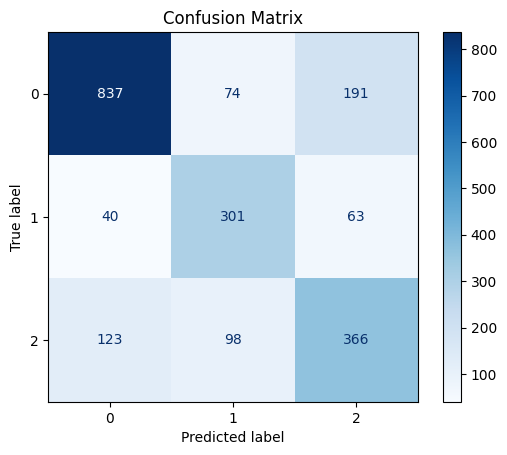

In [419]:
CM = confusion_matrix(prediction, Y_test)
disp = ConfusionMatrixDisplay(confusion_matrix=CM, display_labels=[0,1,2])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()